OBJECTIVES
Your task is to build a simulation model and compare the above inventory policies using the pineapple juice dataset.
The study should answer the following questions:
Which inventory policy achieves the lowest total cost?
Which inventory policy best satisfies the target fill rate of 0.80?
How does policy performance change when demand is influenced by price?
Which policy is the most robust under changes in demand variability, price, and lead time?





Data description and exploratory analysis



Shape of dataset: (366, 3)

Columns:
Index(['Day', 'Demand', 'Price'], dtype='object')

First 5 rows:
   Day  Demand  Price
0    1     131   1.38
1    2     147   1.06
2    3     101   1.98
3    4     139   1.22
4    5     121   1.58

Descriptive statistics:
           Demand       Price
count  366.000000  366.000000
mean   130.581967    1.388361
std     21.321996    0.426440
min     72.000000    0.220000
25%    117.000000    1.100000
50%    130.000000    1.400000
75%    145.000000    1.660000
max    189.000000    2.560000

Correlation between Demand and Price: -1.000000

Estimated demand model:
Demand = 200.00 + (-50.00)*Price


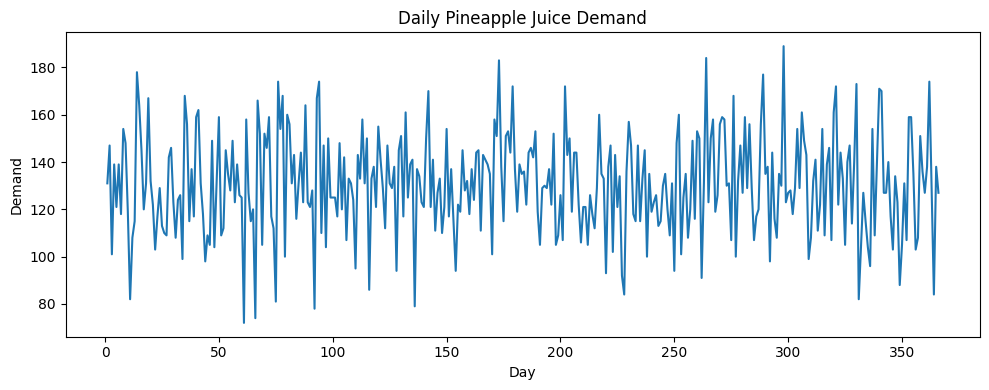

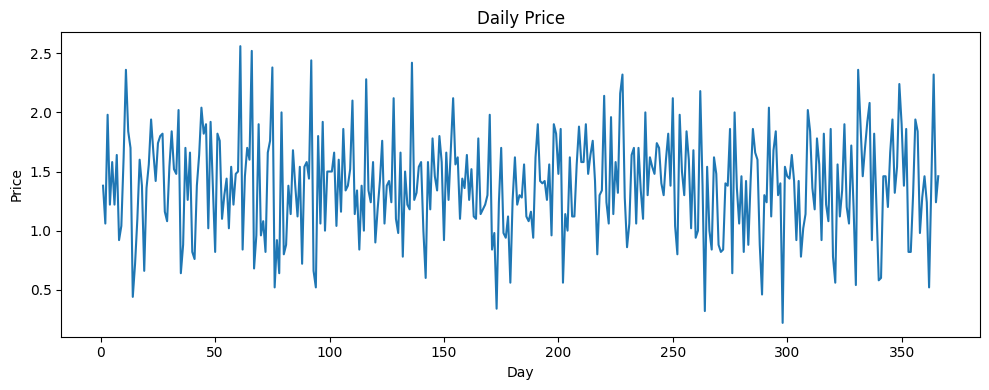

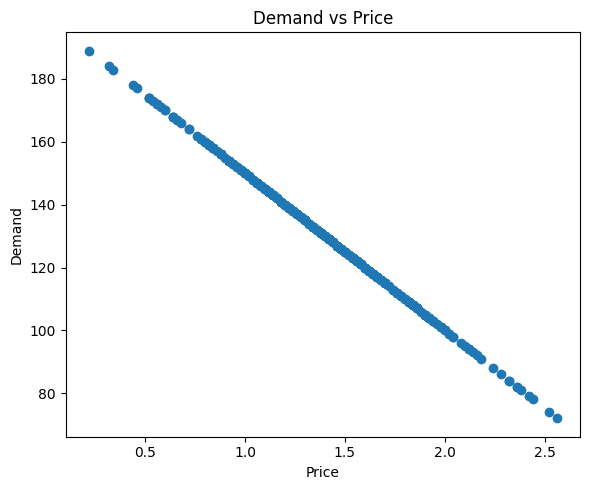

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1.Importing data
pju = pd.read_csv(r"Pinapple_juice.csv")
pju.head()

# 2.Renaming column
pju = pju.rename(columns = {"Pinapple juice": "Demand"})

# 3. Basic information
print("Shape of dataset:", pju.shape)
print("\nColumns:")
print(pju.columns)

print("\nFirst 5 rows:")
print(pju.head())

# 4. Descriptive statistics
print("\nDescriptive statistics:")
print(pju[["Demand", "Price"]].describe())

# 5. Correlation
corr = pju["Demand"].corr(pju["Price"])
print(f"\nCorrelation between Demand and Price: {corr:.6f}")

# 6. Estimate linear relationship manually
# Fit Demand = a + b*Price
b, a = np.polyfit(pju["Price"], pju["Demand"], 1)
print(f"\nEstimated demand model:")
print(f"Demand = {a:.2f} + ({b:.2f})*Price")

# 7. Plot demand over time
plt.figure(figsize=(10, 4))
plt.plot(pju["Day"], pju["Demand"])
plt.xlabel("Day")
plt.ylabel("Demand")
plt.title("Daily Pineapple Juice Demand")
plt.tight_layout()
plt.show()

# 8. Plot price over time
plt.figure(figsize=(10, 4))
plt.plot(pju["Day"], pju["Price"])
plt.xlabel("Day")
plt.ylabel("Price")
plt.title("Daily Price")
plt.tight_layout()
plt.show()

# 9. Scatter plot: demand vs price
plt.figure(figsize=(6, 5))
plt.scatter(pju["Price"], pju["Demand"])
plt.xlabel("Price")
plt.ylabel("Demand")
plt.title("Demand vs Price")
plt.tight_layout()
plt.show()

Assumptions

In [18]:
ASSUMPTIONS = {
    "demand_treatment": "historical_replay",
    "unmet_demand": "lost_sales",
    "lead_time_days": 7,
    "ordering_cost": 100,
    "holding_cost_per_unit_per_day": 5,
    "time_unit": "day",
    "order_arrival_rule": "order_at_end_of_day_arrives_at_start_of_day_t_plus_L",
    "capacity_constraint": None,
    "MOQ": None,
    "perishability": False
}

# Initial inventory = average demand during lead time
mean_daily_demand = pju["Demand"].mean()
lead_time = ASSUMPTIONS["lead_time_days"]

initial_inventory = round(mean_daily_demand * lead_time)

ASSUMPTIONS["initial_inventory"] = initial_inventory

print("Part 3 - Required Assumptions")
for k, v in ASSUMPTIONS.items():
    print(f"{k}: {v}")

# Inventory position formula for lost sales
print("\nInventory position under lost sales:")
print("IP_t = OnHand_t + OnOrder_t")


Part 3 - Required Assumptions
demand_treatment: historical_replay
unmet_demand: lost_sales
lead_time_days: 7
ordering_cost: 100
holding_cost_per_unit_per_day: 5
time_unit: day
order_arrival_rule: order_at_end_of_day_arrives_at_start_of_day_t_plus_L
capacity_constraint: None
MOQ: None
perishability: False
initial_inventory: 914

Inventory position under lost sales:
IP_t = OnHand_t + OnOrder_t


Policies mechanical

In [19]:
# MIN Q
def policy_min_q(ip, r, Q):
  if ip <= r:
    return Q
  return 0

# Min max
def policy_min_max(ip, s, S):
  if ip <= S:
    return S - ip
  return 0

# Hyprid
def policy_hyprid(ip, s, Q, S):
  if ip < s:
    return max(Q, S - ip)
  return 0

# Base stock
def policy_base_stock(ip, S):
  return max(0, S - ip)

# Periodic review
def policy_periodic(ip, day, R, S):
    # review on every R-th day
    if day % R == 0:
        return max(0, S - ip)
    return 0


Simulation


In [20]:
def simulate_inventory(
    pju,
    policy_name,
    params,
    initial_inventory,
    lead_time=7,
    ordering_cost=100,
    holding_cost=5):

    # Initialize the results list
    results = []

    # creating a list of order on-going tuples (arrival_day, quantity)
    pipeline_orders = []

    on_hand = initial_inventory

    for _, row in pju.iterrows():
        day = int(row["Day"])
        demand = float(row["Demand"])

        begin_oh = on_hand

        # 1. Receive replenishments arriving today
        receipts_today = sum(qty for arrival_day, qty in pipeline_orders if arrival_day == day)
        on_hand += receipts_today

        # Remove received orders from pipeline
        pipeline_orders = [(arrival_day, qty) for arrival_day, qty in pipeline_orders if arrival_day != day]

        # 2. Fulfill demand under lost sales
        fulfilled = min(on_hand, demand)
        lost_sales = max(0, demand - on_hand)
        on_hand = max(0, on_hand - demand)

        # 3. Compute on-order and inventory position before ordering
        on_order = sum(qty for _, qty in pipeline_orders)
        ip = on_hand + on_order

        # 4. Apply replenishment policy
        if policy_name == "min_q":
            order_qty = policy_min_q(ip, params["r"], params["Q"])

        elif policy_name == "min_max":
            order_qty = policy_min_max(ip, params["s"], params["S"])

        elif policy_name == "hybrid":
            order_qty = policy_hyprid(ip, params["s"], params["Q"], params["S"])

        elif policy_name == "base_stock":
            order_qty = policy_base_stock(ip, params["S"])

        elif policy_name == "periodic":
            order_qty = policy_periodic(ip, day, params["R"], params["S"])

        else:
            raise ValueError("Unknown policy_name")

        # 5. Place order if any
        if order_qty > 0:
            arrival_day = day + lead_time
            pipeline_orders.append((arrival_day, order_qty))
            current_ordering_cost = ordering_cost # Used parameter ordering_cost
        else:
            arrival_day = None
            current_ordering_cost = 0

        # 6. Holding cost based on end-of-day on-hand inventory
        current_holding_cost = on_hand * holding_cost # Used parameter holding_cost

        # 7. Recompute on_order and IP after ordering
        on_order_after = sum(qty for _, qty in pipeline_orders)
        ip_after = on_hand + on_order_after

        results.append({
            "Day": day,
            "Demand": demand,
            "BeginOH": begin_oh,
            "Receipt": receipts_today,
            "Fulfilled": fulfilled,
            "LostSales": lost_sales,
            "EndOH": on_hand,
            "OnOrder": on_order_after,
            "IP": ip_after,
            "OrderQty": order_qty,
            "ArrivalDay": arrival_day,
            "HoldingCost": current_holding_cost,
            "OrderingCost": current_ordering_cost
        })

    # Corrected indentation for these lines to be within the function but outside the loop
    daily_df = pd.DataFrame(results)

    total_demand = daily_df["Demand"].sum()
    total_fulfilled = daily_df["Fulfilled"].sum()
    total_lost_sales = daily_df["LostSales"].sum()
    total_orders = (daily_df["OrderQty"] > 0).sum()

    summary = {
        "Policy": policy_name,
        "FillRate": total_fulfilled / total_demand if total_demand > 0 else 0,
        "TotalDemand": total_demand,
        "TotalFulfilled": total_fulfilled,
        "TotalLostSales": total_lost_sales,
        "AverageInventory": daily_df["EndOH"].mean(),
        "NumberOfOrders": total_orders,
        "OrderingCost": daily_df["OrderingCost"].sum(),
        "HoldingCost": daily_df["HoldingCost"].sum(),
        "TotalCost": daily_df["OrderingCost"].sum() + daily_df["HoldingCost"].sum()
    }

    return daily_df, summary

Metrics

       Policy  FillRate  TotalDemand  TotalFulfilled  TotalLostSales  \
0  base_stock  0.982466      47793.0         46955.0           838.0   
1       min_q  0.847697      47793.0         40514.0          7279.0   
2     min_max  0.996317      47793.0         47617.0           176.0   
3      hybrid  0.828406      47793.0         39592.0          8201.0   
4    periodic  0.618103      47793.0         29541.0         18252.0   

   AverageInventory  NumberOfOrders  OrderingCost  HoldingCost  TotalCost  \
0         58.437158             366         36600     106940.0   143540.0   
1         93.057377             135         13500     170295.0   183795.0   
2         94.926230             366         36600     173715.0   210315.0   
3        116.516393             109         10900     213225.0   224125.0   
4        182.579235              52          5200     334120.0   339320.0   

   MeetsTarget  
0         True  
1         True  
2         True  
3         True  
4        False  


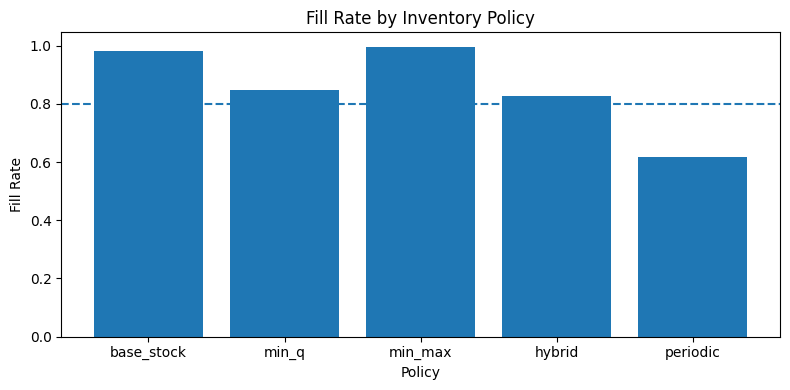

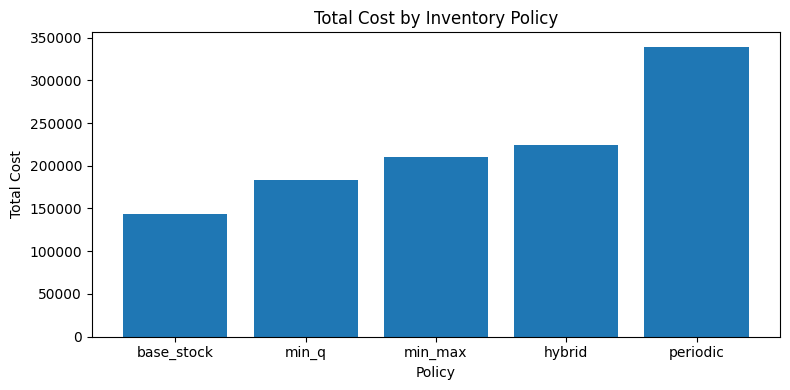

In [22]:
import pandas as pd

# Example parameter set for initial comparison
policies = {
    "min_q": {"r": 700, "Q": 300},
    "min_max": {"s": 700, "S": 1000},
    "hybrid": {"s": 700, "Q": 250, "S": 1000},
    "base_stock": {"S": 950},
    "periodic": {"R": 7, "S": 1000}
}

all_daily_results = {}
all_summaries = []

for policy_name, params in policies.items():
    daily_res, summary = simulate_inventory(
        pju=pju,
        policy_name=policy_name,
        params=params,
        initial_inventory=initial_inventory,
        lead_time=7,
        ordering_cost=100,
        holding_cost=5
    )

    all_daily_results[policy_name] = daily_res
    all_summaries.append(summary)

summary_df = pd.DataFrame(all_summaries)

# Add service target flag
summary_df["MeetsTarget"] = summary_df["FillRate"] >= 0.80

# Sort for easier interpretation
summary_df = summary_df.sort_values(
    by=["MeetsTarget", "TotalCost"],
    ascending=[False, True]
).reset_index(drop=True)

print(summary_df)

plt.figure(figsize=(8, 4))
plt.bar(summary_df["Policy"], summary_df["FillRate"])
plt.axhline(0.80, linestyle="--")
plt.xlabel("Policy")
plt.ylabel("Fill Rate")
plt.title("Fill Rate by Inventory Policy")
plt.tight_layout()
plt.show()



import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.bar(summary_df["Policy"], summary_df["TotalCost"])
plt.xlabel("Policy")
plt.ylabel("Total Cost")
plt.title("Total Cost by Inventory Policy")
plt.tight_layout()
plt.show()